In [3]:
api_key = "YOUR_FRED_API_KEY"

In [5]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
import pandas as pd
from sklearn.decomposition import PCA

/opt/anaconda3/envs/whisper-env/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [6]:
series = [
        (1 / 12, "DGS1MO"),
        (3 / 12, "DGS3MO"),
        (6 / 12, "DGS6MO"),
        (1.0, "DGS1"),
        (2.0, "DGS2"),
        (3.0, "DGS3"),
        (5.0, "DGS5"),
        (7.0, "DGS7"),
        (10.0, "DGS10"),
        (20.0, "DGS20"),
        (30.0, "DGS30")
    ]

In [9]:
def fetch_fred_rate(series_id, api_key):
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        # "sort_order": "desc",
        "observation_start": "2020-01-01",
        "observation_end": "2026-06-17"
        # "limit": 10,
    }

    response = requests.get(url, params)
    df = pd.DataFrame.from_dict(response.json()['observations'])
    df.drop(columns = ['realtime_start', 'realtime_end'], inplace = True)
    df.dropna(axis = 0, inplace = True)
    df = df[df['value'] != '.']
    df.set_index('date', inplace = True)
    df.index = pd.to_datetime(df.index)
    df['value'] = df['value'].astype(float)
    return df

In [11]:
rates = pd.DataFrame()
for t, s_id in series:
    r = fetch_fred_rate(s_id, api_key)
    r.rename(columns = {"value": t}, inplace = True)
    rates = pd.concat([rates, r], axis = 1)
rates.sort_index()
rates.dropna()

,0.083333,0.250000,0.500000,1.000000,2.000000,3.000000,5.000000,7.000000,10.000000,20.000000,30.000000
date,,,,,,,,,,,
2020-01-02,1.53,1.54,1.57,1.56,1.58,1.59,1.67,1.79,1.88,2.19,2.33
2020-01-03,1.52,1.52,1.55,1.55,1.53,1.54,1.59,1.71,1.80,2.11,2.26
2020-01-06,1.54,1.56,1.56,1.54,1.54,1.56,1.61,1.72,1.81,2.13,2.28
2020-01-07,1.52,1.54,1.56,1.53,1.54,1.55,1.62,1.74,1.83,2.16,2.31
2020-01-08,1.50,1.54,1.56,1.55,1.58,1.61,1.67,1.78,1.87,2.21,2.35
...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,3.69,3.78,3.81,3.85,4.05,4.09,4.18,4.31,4.45,4.96,4.95
2026-06-12,3.69,3.78,3.82,3.86,4.09,4.12,4.21,4.34,4.48,4.98,4.97
2026-06-15,3.69,3.79,3.81,3.84,4.07,4.10,4.18,4.32,4.47,4.97,4.97


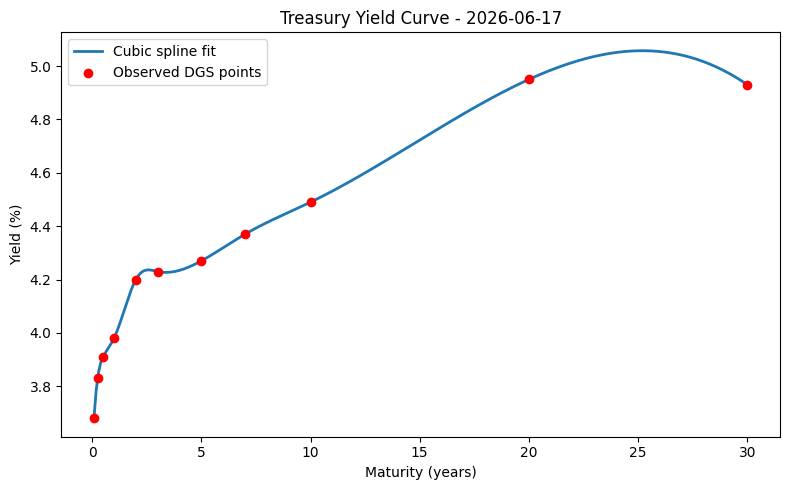

In [20]:
# Cubic Spline
dt = rates.index[-1]
latest_curve = rates.loc[dt].dropna()
tenors = np.array(latest_curve.index)
yields = np.array(latest_curve)
cs = CubicSpline(tenors, yields)

tenor_grid = np.linspace(tenors.min(), tenors.max(), 300)
fitted_yields = cs(tenor_grid)

plt.figure(figsize=(8, 5))
plt.plot(tenor_grid, fitted_yields, label="Cubic spline fit", linewidth=2)
plt.scatter(tenors, yields, color="red", label="Observed DGS points", zorder=3)
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.title(f"Treasury Yield Curve - {dt.date()}")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# PCA
daily_changes_bp = rates.diff().dropna()*100 # Daily yield changes in basis points

pca = PCA(n_components = 3)
pca.fit(daily_changes_bp)

print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.7223892  0.10802812 0.09505242]
0.9254697440699561


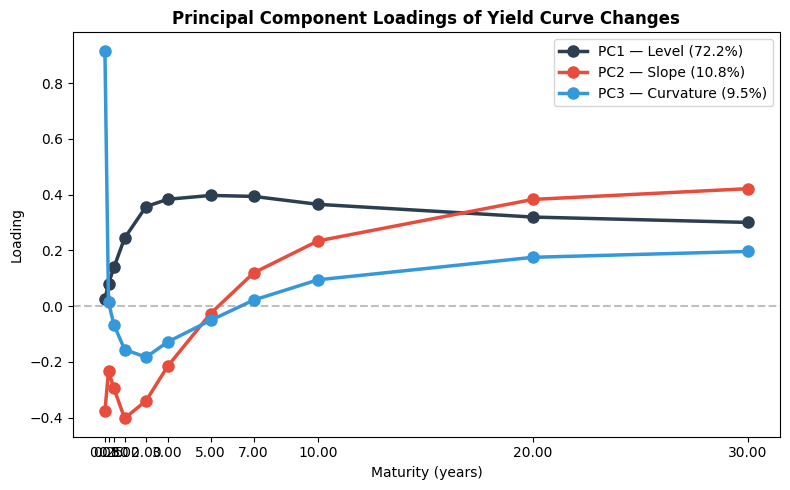

In [50]:
maturities_years = np.array(rates.columns)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2c3e50', '#e74c3c', '#3498db']
labels = ['PC1 — Level', 'PC2 — Slope', 'PC3 — Curvature']

for i in range(3):
    pct = pca.explained_variance_ratio_[i] * 100
    ax.plot(maturities_years, pca.components_[i], marker='o', linewidth=2.5,
            markersize=8, color=colors[i],
            label=f'{labels[i]} ({pct:.1f}%)')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Loading')
ax.set_title('Principal Component Loadings of Yield Curve Changes', fontweight='bold')
ax.set_xticks(maturities_years)
ax.legend()
plt.tight_layout()
plt.show()

In [52]:
scores = pca.transform(daily_changes_bp)
scores_df = pd.DataFrame(scores, index = daily_changes_bp.index, columns = ['PC1', 'PC2', 'PC3'])
scores_df

,PC1,PC2,PC3
date,,,
2020-01-03,-18.807917,-3.934742,-2.517801
2020-01-06,3.704404,-0.346742,2.187443
2020-01-07,2.456774,5.021034,-0.393420
2020-01-08,11.513438,2.270092,-1.884450
2020-01-09,-3.715263,-1.006251,2.827590
...,...,...,...
2026-06-11,-23.586643,-2.547051,-0.453041
2026-06-12,7.192544,-0.019478,-0.510561
2026-06-15,-5.174638,1.289167,0.740673


In [54]:
pc_contribs = {}
for i in range(3):
    pc_contribs["PC{0}".format(i+1)] = np.outer(scores[:, i], pca.components_[i])

reconstructed_curve = pca.mean_ + sum(pc_contribs.values())
residual = daily_changes_bp.to_numpy() - reconstructed_curve

In [56]:
actual_move_latest = daily_changes_bp.iloc[-1].to_numpy()
pc1_move_latest = pc_contribs["PC1"][-1]
pc2_move_latest = pc_contribs["PC2"][-1]
pc3_move_latest = pc_contribs["PC3"][-1]
reconstructed_curve_latest = reconstructed_curve[-1]
residual_move_latest = residual[-1]

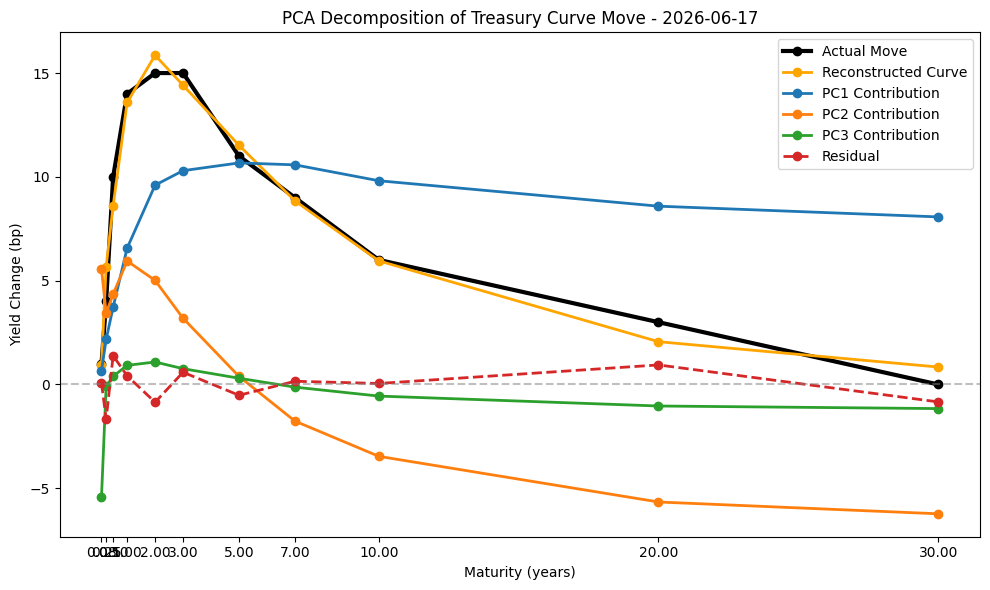

In [58]:
tenors = daily_changes_bp.columns.astype(float).to_numpy()

plt.figure(figsize=(10, 6))

plt.plot(tenors, actual_move_latest, marker='o', linewidth=3, label='Actual Move', color='black')
plt.plot(tenors, reconstructed_curve_latest, marker='o', linewidth=2, label='Reconstructed Curve', color = 'orange')
plt.plot(tenors, pc1_move_latest, marker='o', linewidth=2, label='PC1 Contribution')
plt.plot(tenors, pc2_move_latest, marker='o', linewidth=2, label='PC2 Contribution')
plt.plot(tenors, pc3_move_latest, marker='o', linewidth=2, label='PC3 Contribution')
plt.plot(tenors, residual_move_latest, marker='o', linewidth=2, linestyle='--', label='Residual')

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Maturity (years)')
plt.ylabel('Yield Change (bp)')
plt.title(f'PCA Decomposition of Treasury Curve Move - {dt.date()}')
plt.xticks(tenors)
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
def bond_pricer(face_value, c, T, r, f):
    pv = 0
    n = int(round(f*T))
    for i in range(n):
        cf = (c/f)*face_value
        if i == n - 1:
            cf += face_value
        dcf = cf/pow(1+r/f, i + 1)
        pv += dcf
    return pv

In [62]:
def bond_dv_01(face_value, c, T, r, f):
    bump = 0.0001

    price_down = bond_pricer(face_value, c, T, r - bump, f)
    price_up = bond_pricer(face_value, c, T, r + bump, f)

    return (price_down - price_up)/2

In [64]:
bond_dv_01(1, 0.05, 2, 0.03, 2)

0.00019743067959399063

In [66]:
portfolio = pd.DataFrame({
    "bond": ["2Y Note", "5Y Note", "10Y Note", "30Y Bond"],
    "face_value": [5_000_000, 4_000_000, 3_000_000, 2_000_000],
    "coupon": [0.040, 0.042, 0.045, 0.047],
    "maturity": [2, 5, 10, 30],
    "frequency": [2, 2, 2, 2],
    "positions": [1, 1, 1, 1]
})

latest_curve_decimal = rates.iloc[-1]/100
portfolio["ytm"] = portfolio["maturity"].map(latest_curve_decimal)

portfolio["price"] = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                             row["maturity"], row["ytm"], row["frequency"]), axis = 1)

portfolio["dv01"] = portfolio.apply(lambda row: bond_dv_01(row["face_value"], row["coupon"],
                                                             row["maturity"], row["ytm"], row["frequency"]), axis = 1)
portfolio["signed_dv01"] = portfolio["dv01"]*portfolio["positions"]
total_signed_dv_01 = portfolio["dv01"].sum()
print(total_signed_dv_01)

8158.494952108362


In [68]:
def bump_curve(rate_curve, maturity):
    bump = 0.0001
    rate_curve_up = rate_curve.copy()
    rate_curve_down = rate_curve.copy()
    rate_curve_up.loc[maturity] += bump
    rate_curve_down.loc[maturity] -= bump
    return rate_curve_up, rate_curve_down

In [70]:
portfolio = pd.DataFrame({
    "bond": ["2Y Note", "5Y Note", "10Y Note", "30Y Bond"],
    "face_value": [5_000_000, 4_000_000, 3_000_000, 2_000_000],
    "coupon": [0.040, 0.042, 0.045, 0.047],
    "maturity": [2, 5, 10, 30],
    "frequency": [2, 2, 2, 2],
    "positions": [1, 1, 1, 1]
})

latest_curve_decimal = rates.iloc[-1]/100
portfolio["ytm"] = portfolio["maturity"].map(latest_curve_decimal)

portfolio["price"] = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                             row["maturity"], row["ytm"], row["frequency"]), axis = 1)

portfolio["dv01"] = portfolio.apply(lambda row: bond_dv_01(row["face_value"], row["coupon"],
                                                             row["maturity"], row["ytm"], row["frequency"]), axis = 1)
portfolio["signed_dv01"] = portfolio["dv01"]*portfolio["positions"]
total_signed_dv_01 = portfolio["dv01"].sum()
print(total_signed_dv_01)

8158.494952108362


In [72]:
def bond_pricer(face_value, c, T, rate_curve, cs, f):
    # rates curve must be in decimals
    pv = 0
    n = int(round(f*T))
    for i in range(n):
        t = float((i + 1)/f)
        if t in rate_curve.index:
            r = rate_curve[t]
        else:
            r = float(cs(t))
        
        cf = (c/f)*face_value
        if i == n - 1:
            cf += face_value
        dcf = cf/pow(1+r/f, i + 1)
        pv += dcf
    return pv

In [74]:
portfolio = pd.DataFrame({
    "bond": ["2Y Note", "5Y Note", "10Y Note", "30Y Bond"],
    "face_value": [5_000_000, 4_000_000, 3_000_000, 2_000_000],
    "coupon": [0.040, 0.042, 0.045, 0.047],
    "maturity": [2, 5, 10, 30],
    "frequency": [2, 2, 2, 2],
    "positions": [1, 1, 1, 1]
})

latest_curve_decimal = rates.iloc[-1]/100

delta_ladder = {}

for maturity in latest_curve_decimal.index:
    rates_up, rates_down = bump_curve(latest_curve_decimal, maturity)
    cs_up = CubicSpline(rates_up.index.astype(float).to_numpy(), rates_up.to_numpy(dtype = float))
    cs_down = CubicSpline(rates_down.index.astype(float).to_numpy(), rates_down.to_numpy(dtype = float))
    
    price_up = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                                    row["maturity"], rates_up, cs_up,
                                                                    row["frequency"]), axis = 1)
    
    price_down = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                                    row["maturity"], rates_down, cs_down,
                                                                    row["frequency"]), axis = 1)

    dv01 = (price_down - price_up)/2
    signed_dv01 = dv01*portfolio["positions"]
    total_signed_dv01 = signed_dv01.sum()
    delta_ladder[maturity] = total_signed_dv01

In [134]:
def make_delta_ladder(portfolio, rates_curve):
    
    delta_ladder = []
    
    for maturity in rates_curve.index:
        # Bumping rates for the chosen maturity
        rates_up, rates_down = bump_curve(rates_curve, maturity)
        
        cs_up = CubicSpline(rates_up.index.astype(float).to_numpy(), rates_up.to_numpy(dtype = float))
        cs_down = CubicSpline(rates_down.index.astype(float).to_numpy(), rates_down.to_numpy(dtype = float))
        
        price_up = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                                        row["maturity"], rates_up, cs_up,
                                                                        row["frequency"]), axis = 1)
        
        price_down = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                                        row["maturity"], rates_down, cs_down,
                                                                        row["frequency"]), axis = 1)
    
        dv01 = (price_down - price_up)/2
        signed_dv01 = dv01*portfolio["positions"]
        total_signed_dv01 = signed_dv01.sum()
        delta_ladder.append(total_signed_dv01)

    return np.array(delta_ladder)

In [98]:
# PCA Hedging

In [150]:
p1 = pd.DataFrame({"bond": ["2Y Hedge Note"], "face_value": [1_000_000], 
                                 "coupon": [0.04], "maturity": [2], "frequency": [2], 
                                 "positions": [1]})
p2 = pd.DataFrame({"bond": ["10Y Hedge Note"], "face_value": [1_000_000], 
                                 "coupon": [0.04], "maturity": [10], "frequency": [2], 
                                 "positions": [1]})

p3 = pd.DataFrame({"bond": ["30Y Hedge Bond"], "face_value": [1_000_000], 
                                 "coupon": [0.04], "maturity": [30], "frequency": [2], 
                                 "positions": [1]})

portfolio = pd.DataFrame({
    "bond": ["2Y Note", "5Y Note", "10Y Note", "30Y Bond"],
    "face_value": [5_000_000, 4_000_000, 3_000_000, 2_000_000],
    "coupon": [0.040, 0.042, 0.045, 0.047],
    "maturity": [2, 5, 10, 30],
    "frequency": [2, 2, 2, 2],
    "positions": [1, 1, 1, 1]
})


ladder_p1 = make_delta_ladder(p1, latest_curve_decimal)

ladder_p2 = make_delta_ladder(p2, latest_curve_decimal)

ladder_p3 = make_delta_ladder(p3, latest_curve_decimal)

ladder_portfolio = make_delta_ladder(portfolio, latest_curve_decimal)

v1 = pca.components_[0]
v2 = pca.components_[1]
v3 = pca.components_[2]

a1 = np.dot(v1, ladder_portfolio)
b1 = np.dot(v1, ladder_p1)
c1 = np.dot(v1, ladder_p2)
d1 = np.dot(v1, ladder_p3)

a2 = np.dot(v2, ladder_portfolio)
b2 = np.dot(v2, ladder_p1)
c2 = np.dot(v2, ladder_p2)
d2 = np.dot(v2, ladder_p3)

a3 = np.dot(v3, ladder_portfolio)
b3 = np.dot(v3, ladder_p1)
c3 = np.dot(v3, ladder_p2)
d3 = np.dot(v3, ladder_p3)

A = np.array([[b1, c1, d1], [b2, c2, d2], [b3, c3, d3]])
y = np.array([-a1, -a2, -a3])

h1, h2, h3 = np.linalg.solve(A, y)

print(h1)
print(h2)
print(h3)

-2.6096532544413193
-10.3552152452016
0.5726424395602094


In [142]:
A = np.array([[b1, c1], [b2, c2]])
y = np.array([-a1, -a2])
np.linalg.solve(A, y)

array([-4.09948461, -9.12033651])

In [152]:
ladder_portfolio + h1*ladder_p1 + h2*ladder_p2 + h3*ladder_p3

array([-3.29514329e-01,  1.52552930e+00, -6.81609202e-01,  1.03187704e+01,
        4.44563268e+02,  2.88734738e-01,  1.57411399e+03, -2.76156113e+02,
       -4.50639557e+03,  1.11604581e+03,  2.03442505e+03])

In [146]:
ladder_portfolio

array([  -2.92833785,   13.5571197 ,  -13.35264248,   74.7826502 ,
        950.46025228,  212.40040668, 1804.07923354,  346.69613665,
       2310.26951651,  892.72060528, 1589.81673314])